# Data Preparation Ulasan Produk Tokopedia

Notebook ini menyiapkan data ulasan untuk model sentimen, berdasarkan masalah yang ditemukan di `04_eksplorasi_ulasan.ipynb`. Hasilnya disimpan sebagai `Dataset/processed/ulasan_bersih.csv`.

Urutan langkah:

1. Merapikan kolom
2. Membuang ulasan duplikat
3. Membuat label sentimen dari rating
4. Membersihkan teks ulasan
5. Membuang ulasan yang kosong setelah dibersihkan
6. Melihat kata-kata yang paling khas untuk setiap label
7. Pemeriksaan akhir dan menyimpan hasil

In [1]:
import html
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"
WARNA_LABEL = {"positif": BIRU, "negatif": ORANYE}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})


def angka(x):
    return f"{x:,.0f}".replace(",", ".")

## 1. Muat data dan rapikan kolom

Kolom `Unnamed: 0` (nomor baris) dan `sold` dibuang karena tidak dipakai. Nama kolom diganti ke bahasa Indonesia supaya konsisten dengan data produk. Nama produk juga dibersihkan dari kode HTML, misalnya `&#40;` menjadi `(`.

In [3]:
df = pd.read_csv("../Dataset/raw/tokopedia-product-reviews-2019.csv")

df = df.drop(columns=["Unnamed: 0", "sold"]).rename(columns={
    "text": "teks",
    "category": "kategori",
    "product_name": "nama_produk",
    "product_id": "id_produk",
    "shop_id": "id_toko",
    "product_url": "url",
})
df["nama_produk"] = df["nama_produk"].map(html.unescape)

jejak = {"Data awal": len(df)}
df.head()

,teks,rating,kategori,nama_produk,id_produk,id_toko,url
0,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK (AIR NAILER GUN) OSSEL 1022J,102279869,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


## 2. Buang ulasan duplikat

Yang dibuang hanya ulasan dengan teks yang sama di produk yang sama, karena kemungkinan terkirim dua kali. Teks yang sama di produk berbeda tetap disimpan, karena kalimat seperti "Barang sesuai deskripsi" memang wajar ditulis banyak pembeli.

In [4]:
sebelum = len(df)
df = df.drop_duplicates(subset=["teks", "id_produk"]).reset_index(drop=True)
print("Ulasan duplikat dibuang:", sebelum - len(df))

jejak["Setelah buang duplikat"] = len(df)

Ulasan duplikat dibuang: 17


## 3. Buat label sentimen dari rating

Aturan label yang dipakai:

- Bintang 1 dan 2 menjadi `negatif`.
- Bintang 4 dan 5 menjadi `positif`.
- Bintang 3 dibuang, karena isinya sering campuran, misalnya "barang oke tapi pengiriman lama", sehingga labelnya tidak jelas.

Dengan aturan ini model hanya perlu membedakan dua kelas. Jumlah kelas negatif memang jauh lebih sedikit, dan hal ini ditangani di notebook model.

In [5]:
df = df[df["rating"] != 3].copy()
df["label"] = np.where(df["rating"] <= 2, "negatif", "positif")

jejak["Setelah buang bintang 3"] = len(df)
df["label"].value_counts()

label
positif    37842
negatif      925
Name: count, dtype: int64

## 4. Bersihkan teks ulasan

Langkah pembersihan untuk setiap ulasan, berurutan:

1. Kembalikan kode HTML ke karakter aslinya (`&amp;` menjadi `&`). Langkah ini harus paling awal, sebelum tanda baca dibuang. Kalau urutannya dibalik, `&amp;` akan tersisa sebagai kata "amp".
2. Ubah semua huruf menjadi huruf kecil, supaya "Bagus" dan "bagus" dianggap sama.
3. Satukan "terima kasih" menjadi "terimakasih", supaya sama dengan bentuk yang lebih sering dipakai.
4. Buang link, angka, tanda baca, dan emoji. Yang tersisa hanya huruf a sampai z dan spasi.
5. Ringkas huruf yang diulang tiga kali atau lebih menjadi satu huruf. Jadi "baguuus" menjadi "bagus" dan "okkkk" menjadi "ok".
6. Ganti singkatan dan ejaan tidak baku dengan bentuk bakunya memakai kamus `NORMALISASI`. Contohnya, "gk" menjadi "tidak" dan "brg" menjadi "barang".

Ada dua langkah yang sengaja tidak dilakukan:

- Membuang stopword (kata umum seperti "yang", "dan", "di"). Daftar stopword bahasa Indonesia biasanya ikut memuat kata "tidak", "kurang", dan "belum", padahal kata-kata ini penting untuk sentimen. Model di notebook berikutnya (TF-IDF) juga sudah otomatis memberi bobot kecil untuk kata yang muncul di hampir semua ulasan.
- Stemming (mengubah kata ke kata dasar, misalnya "pengiriman" menjadi "kirim"). Stemming untuk bahasa Indonesia lambat dan sering salah pada kata tidak baku. Untuk model pertama, hasilnya dibandingkan dulu tanpa stemming.

Ada juga satu keterbatasan dari langkah 5. Kata yang memang punya huruf ganda dan kebetulan diketik berulang, misalnya "maaaaaf", akan menjadi "maf". Kasus seperti ini jarang, jadi diterima.

In [6]:
NORMALISASI = {
    "ga": "tidak", "gak": "tidak", "gk": "tidak", "tdk": "tidak", "ngga": "tidak",
    "nggak": "tidak", "engga": "tidak", "enggak": "tidak", "ndak": "tidak", "nda": "tidak",
    "kagak": "tidak", "gag": "tidak", "tak": "tidak",
    "yg": "yang",
    "dgn": "dengan", "dg": "dengan",
    "sdh": "sudah", "udah": "sudah", "udh": "sudah", "dah": "sudah", "sdah": "sudah",
    "uda": "sudah",
    "brg": "barang", "brang": "barang", "barng": "barang", "barangnya": "barang",
    "brng": "barang",
    "bgt": "banget", "bngt": "banget",
    "tp": "tapi", "tpi": "tapi",
    "jg": "juga",
    "blm": "belum", "blum": "belum",
    "krn": "karena", "krna": "karena", "karna": "karena",
    "utk": "untuk", "untk": "untuk",
    "bs": "bisa", "bsa": "bisa",
    "sy": "saya",
    "trs": "terus", "trus": "terus",
    "sm": "sama",
    "klo": "kalau", "kalo": "kalau", "kl": "kalau",
    "aja": "saja", "aj": "saja",
    "bnyk": "banyak",
    "lg": "lagi",
    "org": "orang",
    "pake": "pakai", "pke": "pakai",
    "dipake": "dipakai",
    "gmn": "bagaimana", "gimana": "bagaimana",
    "knp": "kenapa",
    "dr": "dari",
    "msh": "masih",
    "sdikit": "sedikit", "sdkit": "sedikit", "dikit": "sedikit",
    "kcwa": "kecewa",
    "pdhl": "padahal", "pdahal": "padahal",
    "hrs": "harus",
    "bnr": "benar", "bener": "benar",
    "ckp": "cukup",
    "bkn": "bukan",
    "lbh": "lebih",
    "bgs": "bagus",
    "tgl": "tanggal",
    "hr": "hari",
    "jd": "jadi", "jdi": "jadi",
    "sampe": "sampai", "nyampe": "sampai", "nyampai": "sampai", "smpe": "sampai",
    "smp": "sampai",
    "dateng": "datang",
    "cepet": "cepat", "cpt": "cepat",
    "mantab": "mantap", "mantul": "mantap", "mantep": "mantap",
    "oke": "ok", "okay": "ok", "okey": "ok", "okee": "ok",
    "gpp": "tidak apa apa",
    "tq": "terimakasih", "thx": "terimakasih", "thanks": "terimakasih", "thank": "terimakasih",
    "trims": "terimakasih", "makasih": "terimakasih", "mksh": "terimakasih",
    "trimakasih": "terimakasih", "trimakasi": "terimakasih", "makasi": "terimakasih",
    "terimakasi": "terimakasih", "tks": "terimakasih",
    "recomended": "recommended", "rekomended": "recommended", "recommend": "recommended",
    "rekomen": "recommended", "recomend": "recommended", "rekomendasi": "recommended",
    "rapih": "rapi",
    "pengirimannya": "pengiriman",
    "packingnya": "packing",
    "sellernya": "seller", "slr": "seller",
    "ssuai": "sesuai", "sesua": "sesuai",
    "kualitasnya": "kualitas",
    "mf": "maaf", "maap": "maaf",
    "dlm": "dalam",
    "dpt": "dapat",
    "ksh": "kasih",
    "ny": "nya",
    "cm": "cuma",
    "dsni": "disini",
    "sipp": "sip",
    "joss": "jos",
    "yaa": "ya", "yah": "ya",
    "god": "good", "gud": "good",
}

In [7]:
def bersihkan_teks(teks):
    teks = html.unescape(str(teks))
    teks = teks.lower()
    teks = teks.replace("terima kasih", "terimakasih")
    teks = re.sub(r"https?://\S+|www\.\S+", " ", teks)
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"([a-z])\1{2,}", r"\1", teks)
    kata = [NORMALISASI.get(k, k) for k in teks.split()]
    return " ".join(kata)

Seperti di data prep produk, fungsinya diuji dulu dengan contoh sebelum dipakai ke seluruh data.

In [8]:
contoh = pd.DataFrame([
    ("Goood banget gan!!!", "good banget gan"),
    ("Terima kasih, barang udah sampe &amp; rapih", "terimakasih barang sudah sampai rapi"),
    ("Brg gk sesuai, kecewaaa 😡", "barang tidak sesuai kecewa"),
    ("Barang tdk berfungsi, sdh chat seller tp gk dibales", "barang tidak berfungsi sudah chat seller tapi tidak dibales"),
    ("gara&#34; salah kurir", "gara salah kurir"),
    ("Pengiriman 2 hari, cepet!", "pengiriman hari cepat"),
    ("👍👍👍", ""),
    ("......", ""),
], columns=["teks", "harapan"])

contoh["hasil"] = contoh["teks"].map(bersihkan_teks)
contoh["sesuai"] = contoh["hasil"] == contoh["harapan"]
contoh

,teks,harapan,hasil,sesuai
0,Goood banget gan!!!,good banget gan,good banget gan,True
1,"Terima kasih, barang udah sampe &amp; rapih",terimakasih barang sudah sampai rapi,terimakasih barang sudah sampai rapi,True
2,"Brg gk sesuai, kecewaaa 😡",barang tidak sesuai kecewa,barang tidak sesuai kecewa,True
3,"Barang tdk berfungsi, sdh chat seller tp gk di...",barang tidak berfungsi sudah chat seller tapi ...,barang tidak berfungsi sudah chat seller tapi ...,True
4,gara&#34; salah kurir,gara salah kurir,gara salah kurir,True
5,"Pengiriman 2 hari, cepet!",pengiriman hari cepat,pengiriman hari cepat,True
6,👍👍👍,,,True
7,......,,,True


In [9]:
assert contoh["sesuai"].all(), "Ada contoh yang hasilnya tidak sesuai"

In [10]:
df["teks_bersih"] = df["teks"].map(bersihkan_teks)

with pd.option_context("display.max_colwidth", 90):
    display(df[["teks", "teks_bersih"]].sample(10, random_state=5))

,teks,teks_bersih
25982,"Packing rapi, pengiriman sangat cepat, barang sesuai deskripsi",packing rapi pengiriman sangat cepat barang sesuai deskripsi
28650,"cakep, responsif, sesuai pesanan, harga terbaik, berfungsi dengan baik. thanks",cakep responsif sesuai pesanan harga terbaik berfungsi dengan baik terimakasih
22035,"Kualitas produk yang disarankan oleh seller, terbaik!! Tombol responsif dan kualitas t...",kualitas produk yang disarankan oleh seller terbaik tombol responsif dan kualitas terb...
33927,"ok, makasih atas kerjasamanya . . . . . . . .",ok terimakasih atas kerjasamanya
9066,Barang d terima dengan baik. Kualitas barang oke. Sudah d coba dan nyaman d gunakan.,barang d terima dengan baik kualitas barang ok sudah d coba dan nyaman d gunakan
30046,Barang ori dan kirim hanya 1 hari,barang ori dan kirim hanya hari
2185,gooooooooooooooooooood,good
3594,"Good stuff , great packaging",good stuff great packaging
22183,Bagus Om .... berfungsi dengan baik ... sukses !,bagus om berfungsi dengan baik sukses
32196,"proses cepat, sesuai pesanan",proses cepat sesuai pesanan


## 5. Buang ulasan yang kosong setelah dibersihkan

Ulasan yang hanya berisi emoji, angka, atau tanda baca menjadi teks kosong. Ulasan seperti ini tidak bisa dipelajari model, jadi dibuang.

In [11]:
kosong = df["teks_bersih"].str.strip() == ""
print("Ulasan kosong setelah dibersihkan:", kosong.sum())
print(df.loc[kosong, "teks"].head(8).tolist())

df = df[~kosong].reset_index(drop=True)
jejak["Setelah buang teks kosong"] = len(df)

Ulasan kosong setelah dibersihkan: 182
['👍👍👍👍👍👍👍', '......................', '......................', '👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻👍🏻', '👍👍👍👍👍👍👍', '..................................', '👌🏻👌🏻👌🏻👌🏻👌🏻👌🏻👌🏻👌🏻👌🏻👌🏻', '!!!!!!!!!!!!!!!!!!!!!!!!!!!!']


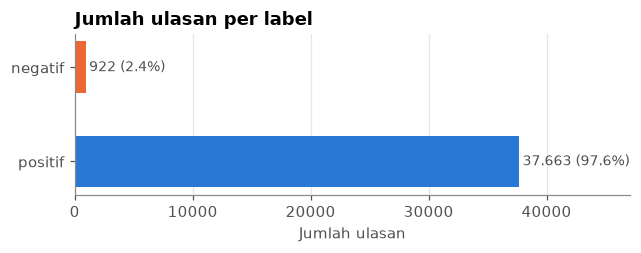

In [12]:
jumlah = df["label"].value_counts()

fig, ax = plt.subplots(figsize=(6, 2.4))
ax.barh(jumlah.index, jumlah.values, color=[WARNA_LABEL[l] for l in jumlah.index], height=0.55)
for y, v in enumerate(jumlah.values):
    ax.text(v + 300, y, f"{angka(v)} ({v / len(df):.1%})", va="center", fontsize=9, color=TEKS)
ax.set_xlim(0, jumlah.max() * 1.25)
ax.set_title("Jumlah ulasan per label")
ax.set_xlabel("Jumlah ulasan")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Setelah bintang 3 dibuang, ulasan negatif hanya 2,4% dari data (922 ulasan). Rasionya kira-kira 1 negatif untuk setiap 41 positif.

## 6. Kata yang paling khas untuk setiap label

Kata yang paling sering muncul, seperti "barang" dan "sesuai", muncul di kedua label sehingga tidak banyak membantu. Yang lebih berguna adalah kata yang jauh lebih sering muncul di satu label dibanding label lainnya.

Caranya: untuk setiap kata, hitung persentase ulasan negatif yang memuat kata itu, lalu bandingkan dengan persentase ulasan positif yang memuat kata yang sama. Hasil bagi keduanya disebut rasio. Rasio 10 berarti kata itu 10 kali lebih sering muncul di ulasan negatif. Hanya kata yang muncul di minimal 20 ulasan yang dihitung, supaya kata langka tidak mendominasi.

In [13]:
kata_per_ulasan = df.assign(kata=df["teks_bersih"].str.split().map(set)).explode("kata", ignore_index=True)
porsi = pd.crosstab(kata_per_ulasan["kata"], kata_per_ulasan["label"])
porsi = porsi[porsi.sum(axis=1) >= 20]

jumlah_label = df["label"].value_counts()
persen_neg = (porsi["negatif"] + 1) / jumlah_label["negatif"]
persen_pos = (porsi["positif"] + 1) / jumlah_label["positif"]
rasio = (persen_neg / persen_pos).rename("rasio")

khas_negatif = rasio.sort_values(ascending=False).head(15)
khas_positif = (1 / rasio).sort_values(ascending=False).head(15)

Angka `+ 1` di rumus di atas mencegah pembagian dengan nol untuk kata yang tidak pernah muncul di salah satu label.

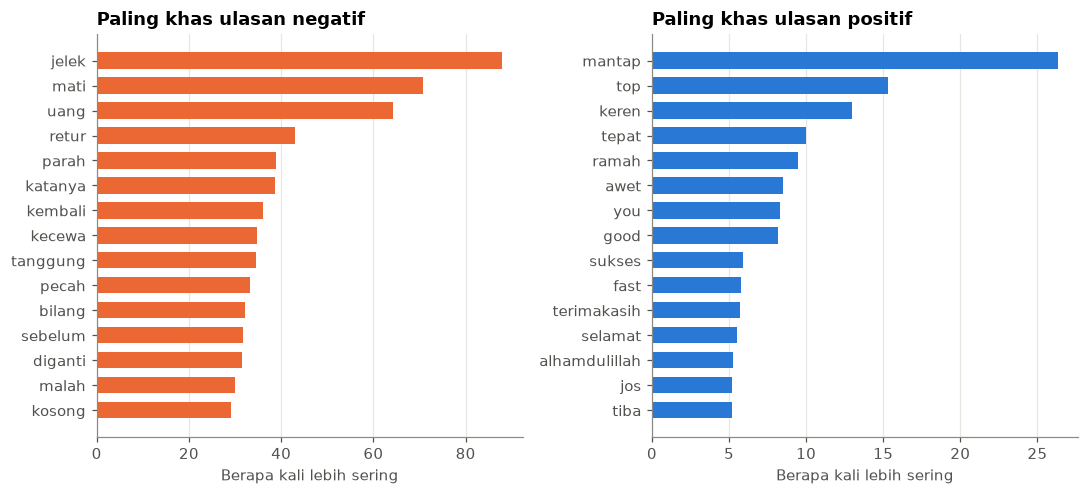

In [14]:
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, data, warna, judul in [
    (kiri, khas_negatif, ORANYE, "Paling khas ulasan negatif"),
    (kanan, khas_positif, BIRU, "Paling khas ulasan positif"),
]:
    data = data.sort_values()
    ax.barh(data.index, data.values, color=warna, height=0.65)
    ax.set_title(judul)
    ax.set_xlabel("Berapa kali lebih sering")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Kata-kata ini memberi gambaran awal tentang apa yang akan dipelajari model:

- Kata khas negatif terbagi dalam tiga kelompok. Pertama, kondisi barang: "jelek", "mati", "pecah", dan "kosong". Kedua, tuntutan pembeli: "uang" (dari "uang kembali"), "retur", "diganti", dan "tanggung" (dari "tanggung jawab"). Ketiga, kata-kata yang dipakai saat bercerita tentang masalah: "katanya", "bilang", dan "malah". Kata "kecewa" dan "parah" juga termasuk di sini.
- Kata khas positif umumnya berupa pujian dan ucapan terima kasih, seperti "mantap", "top", "keren", "ramah", "awet", dan "terimakasih". Kata "tepat" kemungkinan berasal dari frasa "tepat waktu".

Kata "tidak" juga sekitar 10 kali lebih sering muncul di ulasan negatif. Kata ini tidak masuk 15 besar karena juga cukup sering muncul di ulasan positif, misalnya "tidak ada cacat" atau "tidak mengecewakan". Makna kata "tidak" bergantung pada kata sesudahnya. Hal ini akan ditangani di notebook model dengan memasukkan pasangan dua kata (bigram), seperti "tidak sesuai" dan "tidak berfungsi".

## 7. Pemeriksaan akhir dan simpan

In [15]:
df = df[["teks", "teks_bersih", "label", "rating", "kategori", "nama_produk", "id_produk", "id_toko", "url"]]
jejak["Data bersih"] = len(df)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38585 entries, 0 to 38584
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   teks         38585 non-null  str  
 1   teks_bersih  38585 non-null  str  
 2   label        38585 non-null  str  
 3   rating       38585 non-null  int64
 4   kategori     38585 non-null  str  
 5   nama_produk  38585 non-null  str  
 6   id_produk    38585 non-null  int64
 7   id_toko      38585 non-null  int64
 8   url          38585 non-null  str  
dtypes: int64(3), str(6)
memory usage: 12.6 MB


In [16]:
df.to_csv("../Dataset/processed/ulasan_bersih.csv", index=False)

cek = pd.read_csv("../Dataset/processed/ulasan_bersih.csv")
print(cek.shape)
print(cek["label"].value_counts())

(38585, 9)
label
positif    37663
negatif      922
Name: count, dtype: int64


In [17]:
pd.Series(jejak, name="jumlah ulasan").to_frame()

,jumlah ulasan
Data awal,40607
Setelah buang duplikat,40590
Setelah buang bintang 3,38767
Setelah buang teks kosong,38585
Data bersih,38585


## Ringkasan

| Masalah di eksplorasi | Penanganan |
|---|---|
| 1. Rating tidak seimbang | Dicatat. Ditangani di notebook model |
| 2. Label dari rating | Bintang 1 sampai 2 negatif, 4 sampai 5 positif, bintang 3 dibuang |
| 3. Label noise | Diterima sebagai keterbatasan |
| 4. Kode HTML | Dikembalikan ke karakter asli dengan `html.unescape`, sebelum tanda baca dibuang |
| 5. Singkatan dan ejaan tidak baku | Dinormalisasi dengan kamus `NORMALISASI` |
| 6. Huruf berulang, titik, dan emoji | Huruf berulang diringkas, tanda baca dan emoji dibuang |
| 7. Kata "tidak" penting untuk sentimen | Stopword tidak dibuang |
| 8. Ulasan kosong setelah dibersihkan | Dibuang |
| 9. Duplikat | Teks sama di produk yang sama dibuang |
| 10. Kolom tidak berguna | `Unnamed: 0` dan `sold` dibuang |
| 11. Ulasan negatif terpusat di handphone | Dicatat sebagai keterbatasan model |

Hal yang perlu diingat di notebook model:

- Kelas negatif hanya 2,4% dari data, jadi penilaian model harus fokus pada seberapa baik model mengenali ulasan negatif, bukan akurasi keseluruhan.
- Kamus normalisasi hanya mencakup singkatan yang paling sering. Singkatan yang jarang tetap tertulis apa adanya.
- Fungsi `bersihkan_teks` yang sama harus dipakai lagi untuk ulasan baru yang dianalisis di dashboard, supaya teks yang dibaca model selalu diolah dengan cara yang sama.